Matthew Shumaker

Prof. Smiley & Prof. Tardy

Elements of Computing II

5 May 2026

Final Exam

# **Elements of Computing Final Exam_Part 1:** Luxury Dealership Business Use Case using SQLite with Python


---

# **Project Overview**

As the in-house Marketing and Information Specialist for Elite Motor Dealership, you will analyze historical sales data from the `Luxury_Car_Dlrshp.db` database to drive data-led decision-making at the dealership.

# **Your Task:**

* **Step One -** Upload database to notebook environment. (0 pts)
* **Step Two -** Imports and SQLite database connection. (0 pts)
* **Step Three -** Confirm all tables present in database (0 pts)
* **Step Four -** Complete correctly the (5) SQL queries for total revenue and profit KPIs prompts. (5 pts / each)
* **Step Five -** Complete correctly the (3) SQL queries for customer and sales performance prompts. (5 pts / each)
* **Step Six -** Complete correctly the (2) SQL queries for trade-ins and finance analysis prompts. (5 pts / each)

###**For each prompt, you must:**

- **Task 1:** Execute the correct SQL code.

> **Note** - *"correct"*   SQL code is a query that returns an output that completes all elements of the original prompt.

- **Task 2:** Provide a clear answer to the prompt provided for each query based on your returned output.

- **Task 3:** Offer a strategic suggestion for management at Elite Motor Dealership, identifying how these insights (query returns) can improve business KPIs and or reveal new market opportunities.


# **STEP ONE**

*   Upload the `Luxury_Car_Dlrshp.db` into the "Files" section of this notebook.

    **Note** - This file should appear to the left of this cell once successfully added to "Files".

# **STEP TWO**

*   Import all necessary libraries and packages.
*   Establish the path to the DB stored in Files.

In [391]:
import sqlite3
import pandas as pd

# Set the path to the SQLite database
db_path = "./Luxury_Car_Dlrshp.db"

# Connect to SQLite database
conn = sqlite3.connect(db_path)

# Confirmation
print("Connected to SQLite  database!")

Connected to SQLite  database!



# **STEP THREE**

Confirm the database contains the following four tables:

*   `customers`
*   `financials`
*   `sold_vehicles`
*   `trades`

By running the code block below.

In [392]:
# Returns all tables in database

query_tables = """SELECT name
                  FROM sqlite_schema
                  WHERE type='table'
                  ORDER BY name;"""

# Execute the query using pd.read_sql
df_tables = pd.read_sql(query_tables, conn)

print("These are the four tables in the database")
print(df_tables)

These are the four tables in the database
            name
0      customers
1     financials
2  sold_vehicles
3         trades


# **STEP FOUR**

## **Focus:** Total Revenue and Profit KPIs

To begin your analysis complete the prompts below that calculate the revenue and gross profit for the Elite Motors Dealership historical sales data.

> Remember, the definition for "revenue" is defined in the *Definitions* section of the **Luxury Dealership Business Use Case.pdf** resource included in the final project zip file.


## **`Prompts:`**
1.   Total revenue and total gross profit (total revenue - total cost) from all sold vehicles.
2.   Average gross profit per vehicle sold.
3.   Total number of vehicles sold yearly, for the last 5 years, by year in descending order.
4.   Total sales by vehicle make, excluding `Lexus`, with the 10 highest total sales at the top of the column. Confirm which vehicle make came in third highest and their total sales.
5.   Total number of sales by inventory type: new `N` and used `U`..



---

`Q1 PROMPT:` Total revenue and total gross profit (revenue - cost) from all sold vehicles.

In [393]:
#Q1 QUERY

query_revenue_grossprofit = """
                            SELECT SUM(sale_price) AS "Total Revenue", SUM(sale_price - total_cost) AS "Total Gross Profit"
                            FROM financials;
                            """

pd.read_sql(query_revenue_grossprofit, conn)

,Total Revenue,Total Gross Profit
0,2.678816e+08,2.516746e+08


`Q1 ANSWER:`
*please state your answer to this query.*



The total revenue is $267,881,600
The total gross profit is $251,674,600

`Q1 ANALYSIS:`
*please state the strategic suggestion or market opportunity you identified for the dealership*


The dealership is taking home about 94% of the total revenue, which is incredibly impressive. The dealership should attempt to maintain these margins for as long as possible.

`Q2 PROMPT:` Average gross profit per vehicle sold.


In [394]:
#Q2 QUERY

query_avg_profit = """
                   SELECT AVG(sale_price - total_cost) AS "Average Gross Profit", AVG(sale_price) AS "Average Sale Price"
                   FROM financials;
                   """

pd.read_sql(query_avg_profit, conn)

,Average Gross Profit,Average Sale Price
0,33228.758602,35368.576786


`Q2 ANSWER:`
*please state your answer to this query.*

The average gross profit is $33,228.75

`Q2 ANALYSIS:`
*please state the strategic suggestion or market opportunity you identified for the dealership*


Given the extremely low costs relative to revenue, the gross profit is exceptionally close to the average sale price per vehicle. This dealership is operating extremely efficiently, so the only strategic suggestion that could be given is to attempt to maintain this level of operations for as long as possible.

`Q3 PROMPT:` Total number of vehicles sold yearly, for the last 5 years, by year in descending order.


In [395]:
#Q3 QUERY

query_total_sales = """
                    SELECT strftime('%Y', deal_date) AS "Year", COUNT(deal_vin) AS "Vehicles Sold"
                    FROM financials
                    GROUP BY year
                    ORDER BY year DESC
                    LIMIT 5;
                    """

pd.read_sql(query_total_sales, conn)

,Year,Vehicles Sold
0,2017,113
1,2016,585
2,2015,572
3,2014,598
4,2013,592


`Q3 ANSWER:`
*please state your answer to this query.*

The dealership sold 113 cars in 2017, 585 in 2016, 572 in 2015, 598 in 2014, and 592 in 2013.

`Q3 ANALYSIS:`
*please state the strategic suggestion or market opportunity you identified for the dealership*


The number of cars sold as stayed relatively stable, hovering around 590 per year. As 2017 is currently in progress, the end-of-year sales will bring to light if the slight downward trend since 2014 is an issue or a matter of natural fluctuation in sales.

`Q4 PROMPT:` Total sales by vehicle make, excluding `Lexus`, with the 10 highest total sales at the top of the column. Confirm which vehicle make came in third highest and their total sales.


In [396]:
#Q4 QUERY

query_make_sales = """
                   SELECT vehicle_make AS "Vehicle Make", SUM(sale_price) AS "Total Sales ($)", COUNT(f.deal_vin) AS "Total Sales (#)"
                   FROM financials f
                   JOIN sold_vehicles s ON s.deal_vin = f.deal_vin
                   WHERE vehicle_make != "lexus"
                   GROUP BY vehicle_make
                   ORDER BY "Total Sales ($)" DESC
                   LIMIT 10;
                   """

pd.read_sql(query_make_sales, conn)

,Vehicle Make,Total Sales ($),Total Sales (#)
0,toyota,3764162.94,222
1,mercedes-benz,1863940.10,91
2,bmw,1667303.02,84
3,honda,1324836.86,96
4,cadillac,1217527.48,77
5,chevrolet,1192364.81,78
6,ford,1037788.73,84
7,jeep,965650.59,71
8,nissan,941004.00,65
9,chrysler,667891.74,60


`Q4 ANSWER:`
*please state your answer to this query.*

Toyota had both the highest sales in monetary value and in number of sales.

`Q4 ANALYSIS:`
*please state the strategic suggestion or market opportunity you identified for the dealership*


It makes sense that Toyota is the largest sales driver for the dealership, as Lexus (the dealership's main brand) is a subsidiary of Toyota. A potential market opportunity is to prioritize sales of Toyota cars, given their similarity to Lexus vehicles and already existing consumer base.

`Q5 PROMPT:` Total number of sales by inventory type: new `N` and used `U`.


In [397]:
#Q5 QUERY

query_new_used = """
                 SELECT inventory_type AS "Inventory Type", COUNT(deal_vin) AS "Total Sales (#)"
                 FROM sold_vehicles
                 GROUP BY inventory_type;
                 """

pd.read_sql(query_new_used, conn)

,Inventory Type,Total Sales (#)
0,N,3998
1,U,3576


`Q5 ANSWER:`
*please state your answer to this query.*

Just over half of the dealership's sales come from new cars, which are primarily Lexus vehicles. They sell have sold 3998 new cars and 3576 used cars.

`Q5 ANALYSIS:`
*please state the strategic suggestion or market opportunity you identified for the dealership*


My strategic suggestion is to maintain or grow their used car business. As their new car segment has had consistenly high sales, finding new growth opportunities would do well to maintain the operational efficiency of the dealership.



---


# **Customer and Sales Performance:**

To continue your analysis complete these prompts below to identify top customers and sales performance by vehicle category.

## **`Prompts:`**

6.   Total vehicles sold for the top 5 customer cities in descending order by total sales. State which `city` is number 1 in total sales.
7.   Top ten postal codes with the highest overall sales as `total_sales` in descending order. The Elite Motors Dealership resides in the 46545 postal code. State the total sales for this postal code.
8.   State the most frequent and least frequent contract term types and their total count.

> **Note**, the observation of `1` in column `contract_term` means the customer paid for the vehicle with cash (1 time) and not through a loan.



`Q6 PROMPT:` Total vehicles sold for the top 5 customer cities in descending order by total sales. State which `city` is number 1 in total sales.


In [398]:
#Q6 QUERY

query_top_customers = """
                      SELECT city, COUNT(purchase_vin) AS "Total Vehicle Sales"
                      FROM customers c
                      JOIN sold_vehicles s on s.deal_vin = c.purchase_vin
                      GROUP BY city
                      ORDER BY "Total Vehicle Sales" DESC
                      LIMIT 5;
                      """

pd.read_sql(query_top_customers, conn)

,city,Total Vehicle Sales
0,South Bend,1913
1,Granger,1223
2,Elkhart,721
3,Mishawaka,697
4,Saint Joseph,319


`Q6 ANSWER:`
*please state your answer to this query.*

The city with the highest total sales is South Bend, with other cities in the Michiana region following behind.

`Q6 ANALYSIS:`
*please state the strategic suggestion or market opportunity you identified for the dealership*


With its heavy presence in the Michiana region, playing up connections to local institutions and iconography could benefit the dealership. Dealerships with prominent brands like the South Bend Cubs, Four Winds, and potentially finding inspiration from the local university's Irish branding.

`Q7 PROMPT:` Top ten postal codes with the highest overall sales as `total_sales` in descending order. The Elite Motors Dealership resides in the 46545 postal code. State the total sales for this postal code.


In [399]:
#Q7 QUERY

query_postalcodes = """
                    SELECT postal_code, SUM(sale_price) AS "Total Sales ($)", COUNT(deal_vin) AS "Total Sales (#)"
                    FROM customers c
                    JOIN financials f ON f.deal_vin = c.purchase_vin
                    GROUP BY postal_code
                    ORDER BY "Total Sales ($)" DESC
                    LIMIT 10;
                    """

pd.read_sql(query_postalcodes, conn)

,postal_code,Total Sales ($),Total Sales (#)
0,46530,44791778.64,1221
1,46514,17115116.89,442
2,46628,14521487.55,667
3,46614,14439014.82,437
4,46545,13750555.45,405
5,49085,12688039.63,321
6,49120,11344733.80,293
7,46544,9357274.10,286
8,46637,8718416.41,256
9,46526,7426120.44,210


`Q7 ANSWER:`
*please state your answer to this query.*

The 46545 postal code earned $13,750,555.45 in total from 405 vehicles sold.

`Q7 ANALYSIS:`
*please state the strategic suggestion or market opportunity you identified for the dealership*


The highest sales come not from the immediate postal code surrounding the dealership, but rather areas further out. Increasing marketing in postal codes of similar areas and audiences to ones that have high purchase rates could help boost sales in some of the lower purchasing areas.

`Q8 PROMPT:` Total sales as `term_total` by contract term type. State the most frequent and least frequent contract term types and their total count.

> Note, the observation of 1 in column `contract_term` means the customer paid for the vehicle with cash (1 time) and not through a loan.




In [400]:
#Q8 QUERY

query_term_total = """
                   SELECT contract_term, COUNT(deal_vin) AS term_total
                   FROM financials
                   GROUP BY contract_term
                   ORDER BY term_total DESC;
                   """

pd.read_sql(query_term_total, conn)

,contract_term,term_total
0,1,4497
1,60,1297
2,36,792
3,48,615
4,72,114
5,24,72
6,66,37
7,39,31
8,42,21
9,75,17


`Q8 ANSWER:`
*please state your answer to this query.*

The most frequent contract term type is 1 (payment in cash), and the least frequent contract term is a contract term of 69.

`Q8 ANALYSIS:`
*please state the strategic suggestion or market opportunity you identified for the dealership*


An overwhelming majority of purchasers pay in cash (A contract term of 1). This is great for the dealership, as it minimizes their receivables and increases their liquidity. As it is already popular, it is important to encourage these cash payments to both guarantee their continued popularity and even further increase their frequency relative to other contract terms.

# **Trade-ins and Finance Analysis:**

To finalize your analysis complete these prompts below to identify the financial impact of trades on the overall gross profit for the dealership.

## **`Prompts:`**

9.   Total number of trade-in vehicles.

> **Note -** `Not Applicable` in column `trade_vin` means there was no vehicle traded-in at the time of the sale.

10.  Average profitability of sales transactions with a trade-in versus without a trade-in vehicle.

`Q9 PROMPT:` Total number of trade-in vehicles.

> **Note -** `Not Applicable` in column `trade_vin` means there was no vehicle traded-in at the time of the sale.






In [401]:
#Q9 QUERY

query_trade_count = """
                    SELECT COUNT(trade_number) AS "Total # of Trade-In Vehicles"
                    FROM trades
                    WHERE trade_vin != "Not Applicable"
                    """

pd.read_sql(query_trade_count, conn)

,Total # of Trade-In Vehicles
0,2965


`Q9 ANSWER:`
*please state your answer to this query.*

The total number of trade-in vehicles is 2965.

`Q9 ANALYSIS:`
*please state the strategic suggestion or market opportunity you identified for the dealership*


There are fewer trade-in vehicles than non-trade-ins, which could be caused by a variety of things. My personal strategic suggestion is to continue encouraging individuals to not trade-in, as there is no guarantee that the traded-in car will be saleable. I encourage to continue accepting trade-ins, but only those that can be efficiently resold.

`Q10 PROMPT:` Average profitability of sales transactions with a trade-in versus without a trade-in vehicle.

In [402]:
#Q10 QUERY

#profit over revenue: gross profit margin
# SUM(sale_price - total_cost) AS "Total Gross Profit"

query_profit = """
               SELECT
               CASE
                   WHEN trade_vin != "Not Applicable" THEN 1
                   ELSE 0
               END AS trade_in_status, AVG(sale_price - total_cost) AS average_profit,  AVG((sale_price - total_cost)/sale_price) AS avg_gross_profit_margin
               FROM trades t
               JOIN sold_vehicles s ON s.deal_number = t.trade_number
               JOIN financials f ON f.deal_vin = s.deal_vin
               GROUP BY trade_in_status
               """

pd.read_sql(query_profit, conn)

,trade_in_status,average_profit,avg_gross_profit_margin
0,0,30832.614086,0.908550
1,1,36025.881161,0.921139


`Q10 ANSWER:`
*please state your answer to this query.*

Deals with a trade-in vehicle tend to have a higher average profit of $36,025.88 and a larger average gross profit margin of 92.9%, compared to deals without a trade-in vehicle, which have an average profit of $30,832.61 and an average gross profit margin of about 90.9%

`Q10 ANALYSIS:`
*please state the strategic suggestion or market opportunity you identified for the dealership*


Given the exceptionally high profit margin of any deal at this dealership, the highest priority is to maintain these margins through the cost cutting strategy that appears to already be in place. However, my strategic suggestion, contrary to the previous suggestion given this data with more context, is to encourage trade-in cars, as on average they generate higher profit and have a higher profit margin than non trade-in deals.

# **Visualizations**

### Visualization 1

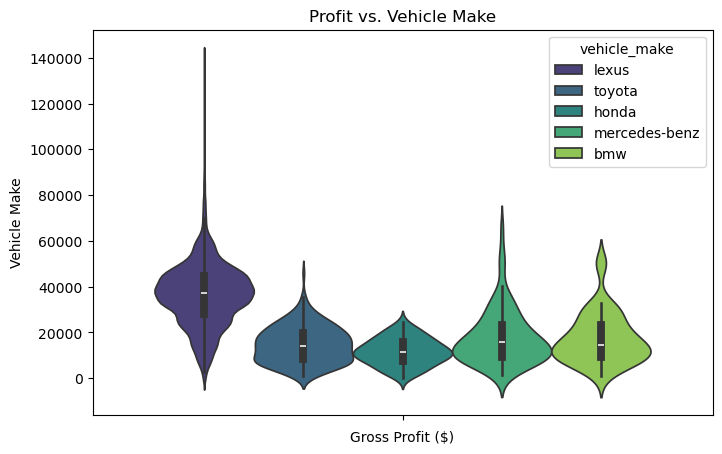

In [403]:
import seaborn as sns
import matplotlib.pyplot as plt

query_make_profit = """
             SELECT vehicle_make, (f.sale_price - f.total_cost) AS profit
             FROM financials f
             JOIN sold_vehicles s ON s.deal_vin = f.deal_vin
             WHERE vehicle_make = "lexus" OR vehicle_make = "toyota" OR vehicle_make = "mercedes-benz" OR vehicle_make = "bmw" OR vehicle_make = "honda";
             """
df_make_profit = pd.read_sql(query_make_profit, conn)

plt.figure(figsize=(8,5))
sns.violinplot(df_make_profit,
               hue = 'vehicle_make',
               y = 'profit',
               palette = 'viridis'
               )

plt.title("Profit vs. Vehicle Make")
plt.xlabel("Gross Profit ($)")
plt.ylabel('Vehicle Make')
plt.show()

I chose a violin plot to gain a deeper insight into how the make of a vehicle affects sales. I chose to include only the top 5 highest selling makes for comparison.

Most of the used cars (primarily non-Lexus) tended to have a similar mean, although they had differing spreads, with some Mercedes-Benz vehicles even selling higher than the new Lexus vehicles the dealership specializes in. Lexus can sell at the very high end, although they generally sell around 20,000 to 30,000 higher than their used cars.

### Visualization 2

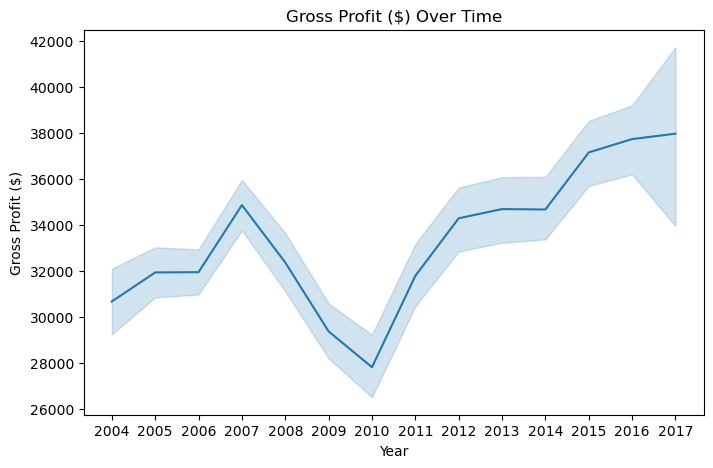

In [404]:
query_profit_year = """
        SELECT strftime('%Y', deal_date) AS year, (sale_price - total_cost) AS profit
        FROM financials
        ORDER BY year ASC;
        """
df_profit_year = pd.read_sql(query_profit_year, conn)

plt.figure(figsize=(8,5))
sns.lineplot(df_profit_year,
             x = 'year',
             y = 'profit'
             )

plt.title("Gross Profit ($) Over Time")
plt.xlabel('Year')
plt.ylabel("Gross Profit ($)")
plt.show()

I chose a line plot to better visualize how profitable the dealership has been over time. I have included all values, showing a spread of all prices while giving an average price line in deeper blue.

Despite early growth, the dealership experienced declining profits from 2007–2010, but quickly recovered and has been on an upward trend from 2011 onward. The spread has also increased, with drastically higher and lower profits particularly in the current year (2017). The downturn from 2007–2010 can be explained for a multitude of reasons which are most likely related to the financial crisis which brought about lower purchases and potentially higher costs.

### Visualization 3

Text(0, 0.5, 'Number Traded-In for a Lexus')

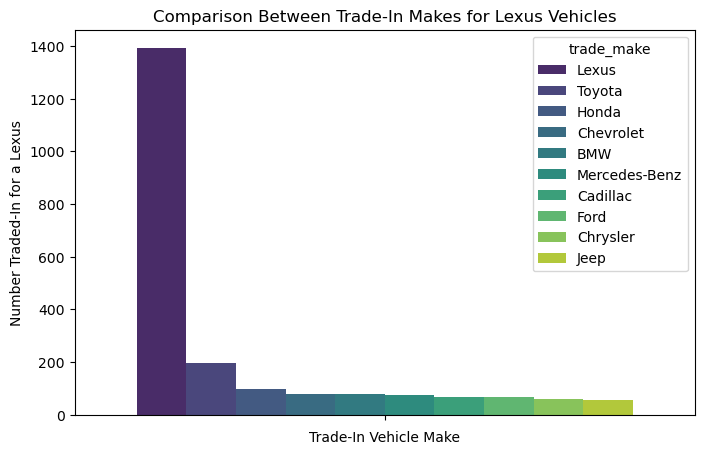

In [405]:
query_trade_in = """
                 SELECT t.trade_make, COUNT(t.trade_make) AS count
                 FROM trades t
                 JOIN sold_vehicles s ON s.deal_number = t.trade_number
                 WHERE trade_make != "Not Applicable" AND vehicle_make = "lexus"
                 GROUP BY t.trade_make
                 ORDER BY count DESC
                 LIMIT 10;
                 """
df_trade_in = pd.read_sql(query_trade_in, conn)

plt.figure(figsize=(8,5))
sns.barplot(df_trade_in,
            hue = 'trade_make',
            y = 'count',
            palette= 'viridis')
plt.title("Comparison Between Trade-In Makes for Lexus Vehicles")
plt.xlabel("Trade-In Vehicle Make")
plt.ylabel("Number Traded-In for a Lexus")

I chose a bar plot to understand what types of cars individuals tended to trade in in return for a Lexus. I was curious if mostly comparable luxury brands were going to trade in. I chose the 10 highest 

In actuality, the large majority (more than all other makes combined) of individuals trading in a car for a Lexus were trading in their own Lexus. The next highest group were trading in Toyota vehicles, which follows as Toyota is Lexus' parent company and is their standard/mainstream brand. The next highest were Hondas, vehicles also made in Japan that target a similar audience to Toyota.

In [406]:
conn.close()